In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [27]:
df = pd.read_csv('../Data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')


# Etape 1: Analyse des données

In [28]:
df.head()



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [29]:
df.shape    # dimensions (nb lignes, nb colonnes)


(7043, 21)

Dimensions:

(7043, 21) → 7043 clients, 21 colonnes

In [30]:
df.info()   # types de données


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Types de données:

Beaucoup de colonnes sont encore en object → certaines devraient être catégorielles (Partner, Contract, etc.).

TotalCharges est encore en object → il faudra absolument le convertir en numérique (float64).

Dans ce dataset, il y a 11 clients avec tenure = 0 et TotalCharges vide.
On va les corriger en mettant TotalCharges = 0.0 (logique : ils n’ont pas encore été facturés).

In [31]:
df.describe()  # stats de base


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Premières stats descriptives:

SeniorCitizen : binaire (0 = non, 1 = oui), seulement 16,2 % de seniors.

tenure : varie de 0 à 72 mois → ça correspond à l’ancienneté du client. Distribution sûrement très informative pour le churn.

MonthlyCharges : varie de 18 à 118 $/mois.

Certains paient peu (services de base), d’autres beaucoup (services multiples).

Ces variables semblent corrélées avec le churn : les clients récents et avec facture élevée risquent plus d’être instables.

# Etape 2 : Nettoyage des données

In [32]:
# # # 1) Conversion de TotalCharges en numérique
# df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


In [33]:
# # # 2) Vérifier les NaN
# print("Nombre de NaN dans TotalCharges:", df['TotalCharges'].isnull().sum())


In [34]:
# # # 3) Corriger les NaN -> clients tenure=0 n'ont pas encore de facture
# df.loc[(df['tenure'] == 0) & (df['TotalCharges'].isnull()), 'TotalCharges'] = 0.0


In [35]:
# # # Vérification après correction
# print("Nombre de NaN restants:", df['TotalCharges'].isnull().sum())


In [36]:
# # 4) Supprimer la colonne customerID (identifiant inutile pour la prédiction)
# df = df.drop(columns=['customerID'])

In [37]:
# # # 5) Convertir les colonnes catégorielles en type 'category'
# for col in df.select_dtypes(include='object').columns:
#     df[col] = df[col].astype('category')

In [38]:
# df.info()

La Transformation à été faites dans le fichier src/transform.py et les données transformées sont stockées dans le fichier data/processed/telco_customer_churn_processed

In [39]:
# Recupération des données transformées pour l'analyse exploratoire
dfp= pd.read_parquet('../data/processed/telco_customer_churn_processed.parquet')

In [40]:
df=dfp.copy()

In [41]:
# Vérification finale
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            7043 non-null   category
 1   SeniorCitizen     7043 non-null   int64   
 2   Partner           7043 non-null   category
 3   Dependents        7043 non-null   category
 4   tenure            7043 non-null   int64   
 5   PhoneService      7043 non-null   category
 6   MultipleLines     7043 non-null   category
 7   InternetService   7043 non-null   category
 8   OnlineSecurity    7043 non-null   category
 9   OnlineBackup      7043 non-null   category
 10  DeviceProtection  7043 non-null   category
 11  TechSupport       7043 non-null   category
 12  StreamingTV       7043 non-null   category
 13  StreamingMovies   7043 non-null   category
 14  Contract          7043 non-null   category
 15  PaperlessBilling  7043 non-null   category
 16  PaymentMethod     7043 n

Bilan: 

-20 colonnes (on a supprimé customerID).

-TotalCharges bien en float64.

-Toutes les variables qualitatives sont en category → top pour la mémoire et les futures analyses.

-Aucun NaN restant.

# Etape 3 Analyse exploratoire (EDA)

## Analyse univariée

Objectif : comprendre la distribution de chaque variable seule.

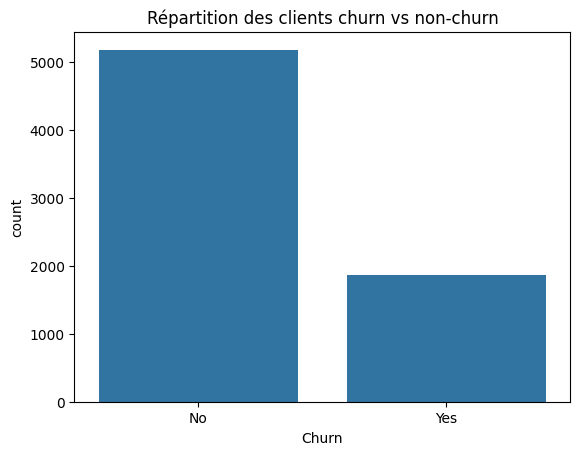

In [42]:
# Distribution de la cible
sns.countplot(data=df, x='Churn')
plt.title("Répartition des clients churn vs non-churn")
plt.show()

### Graphe 1 : Répartition des clients churn vs non-churn

Observation :

~73 % des clients ne quittent pas (Churn = No).

~27 % des clients churnent (Churn = Yes).

Conclusion business :

Le dataset est déséquilibré, mais pas dramatique (≈ 3 pour 1).

En pratique, l’entreprise perd 1 client sur 4, ce qui est énorme dans les télécoms.

Impact ML : il faudra traiter ce déséquilibre avec des techniques comme SMOTE ou du reweighting.

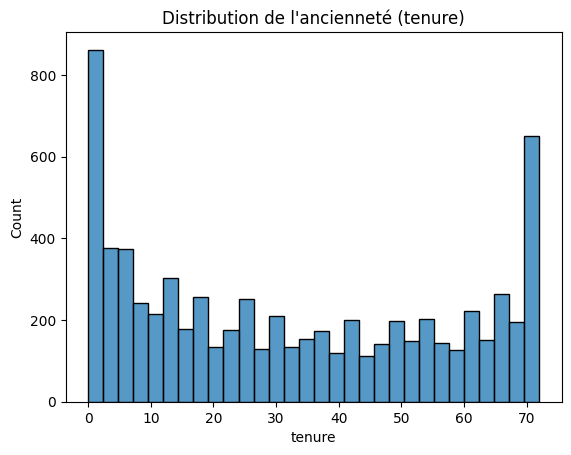

In [43]:
# Histogramme tenure
sns.histplot(df['tenure'], bins=30, kde=False)
plt.title("Distribution de l'ancienneté (tenure)")
plt.show()


### Graphe 2 : Distribution de l’ancienneté (tenure)

Observation :

Beaucoup de clients avec un tenure proche de 0 (nouveaux clients).

Beaucoup de clients avec un tenure élevé (≈ 70 mois) → clients très fidèles.

Entre les deux, la distribution est plus étalée mais avec moins de clients.

Conclusion business :

Il existe deux segments principaux :

Clients récents → plus à risque de churn (ils n’ont pas encore créé de fidélité).

Clients anciens → très fidèles, plus stables.

Insight : l’entreprise devrait mettre en place des programmes de rétention dès les premiers mois (offres d’essai prolongées, réductions initiales).

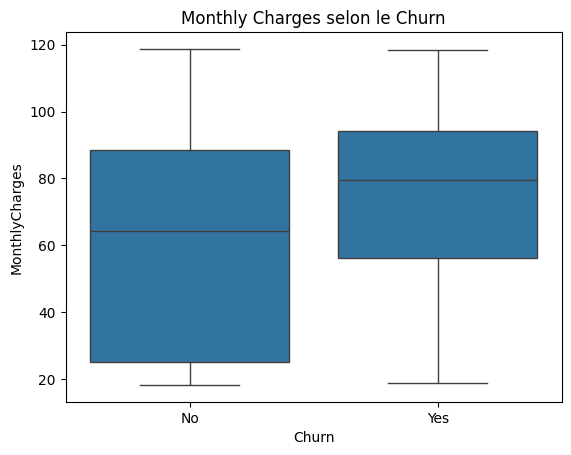

In [44]:
# Boxplot MonthlyCharges
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title("Monthly Charges selon le Churn")
plt.show()


### Graphe 3 : Monthly Charges selon le Churn

Observation :

Les clients qui churnent ont en moyenne une facture plus élevée (≈ 80$) que ceux qui restent (≈ 65$).

La dispersion (variance) est plus forte chez les churners → certains paient énormément et quittent vite.

Conclusion business :

Facture élevée = risque de churn élevé.

Les clients avec plusieurs services (Internet + TV + Sécurité, etc.) payent plus → mais certains quittent car c’est trop cher.

Insight : proposer des packs adaptés (ou des réductions ciblées) pour éviter que les clients à forte facture quittent.

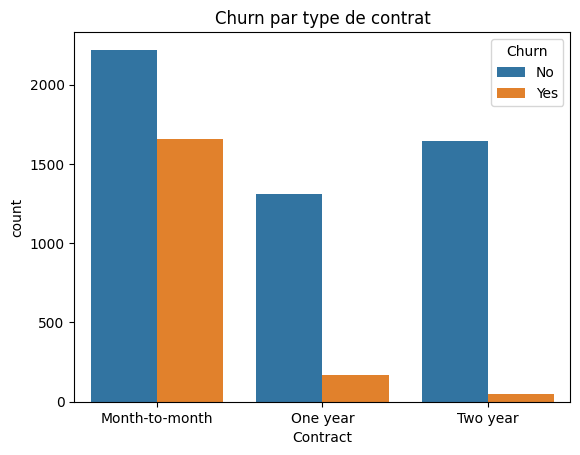

In [45]:
# Countplot Contract
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title("Churn par type de contrat")
plt.show()

### Graphe 4 : Churn par type de contrat

Lecture :

Contrat "Month-to-month" (mensuel) → Très fort taux de churn.
➝ Beaucoup de clients quittent l’opérateur dès qu’ils ont une offre plus attractive ailleurs.

Contrat "One year" → Churn plus faible.

Contrat "Two year" → Quasi pas de churn.

Conclusion business :

Les contrats courts = clients volatils.

Les contrats longs = fidélisation naturelle (probablement grâce à des pénalités de résiliation ou des avantages tarifaires).

Stratégie recommandée : inciter les clients en contrat mensuel à passer sur du 1 an ou 2 ans (remises, bonus, services offerts).

Insight caché : 

Les clients en "Month-to-month" sont souvent aussi ceux qui utilisent Electronic Check comme méthode de paiement (fort lien avec le churn → à vérifier dans l’EDA bivariée).

Business action avancée : au lieu de seulement pousser les clients vers 1 ou 2 ans, on peut aussi :

Ajouter des avantages progressifs avec l’ancienneté (réductions après 6 mois, bonus de data, options gratuites).

Mettre en place des offres d’engagement souples : ex. un contrat d’1 an mais avec possibilité de changer de forfait sans frais → cela rassure et réduit le churn.

## Analyse bivariée

Objectif : voir les relations entre les variables et le churn.

On va comparer la répartition de chaque modalité selon Churn :

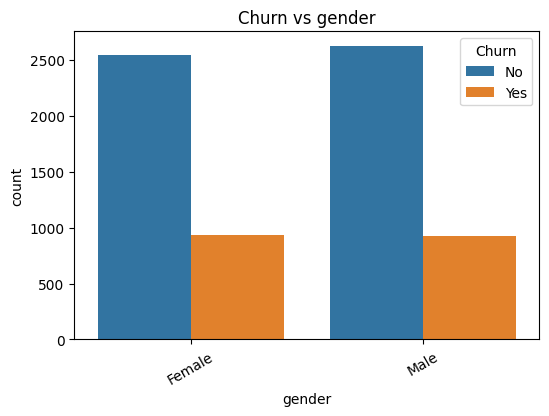

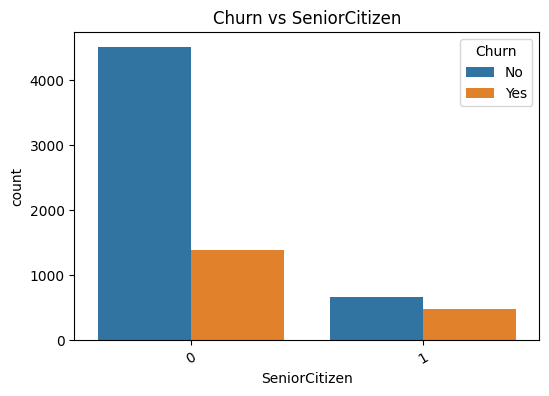

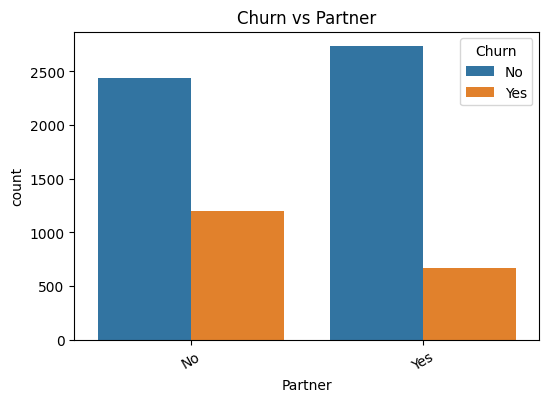

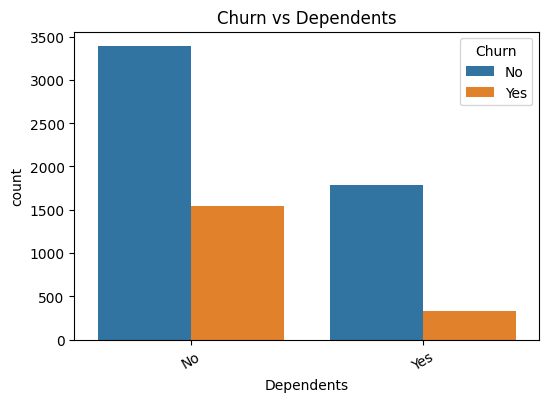

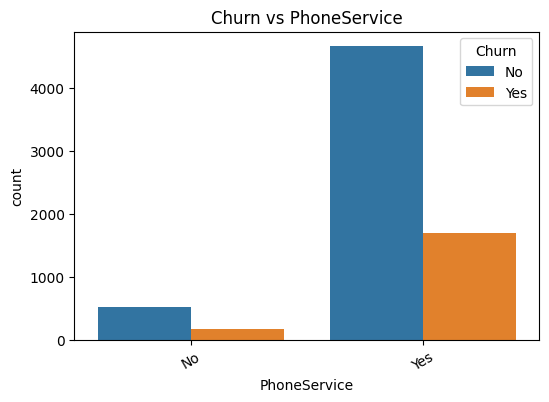

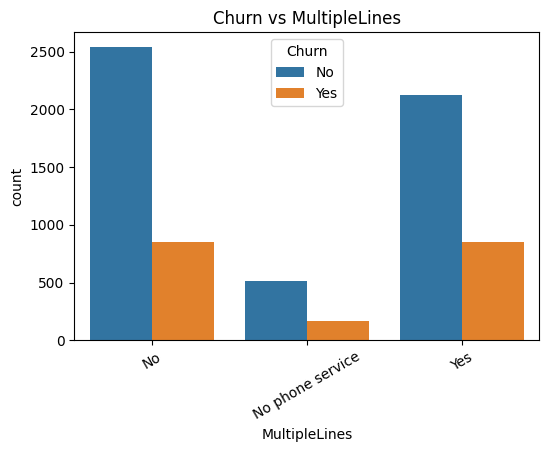

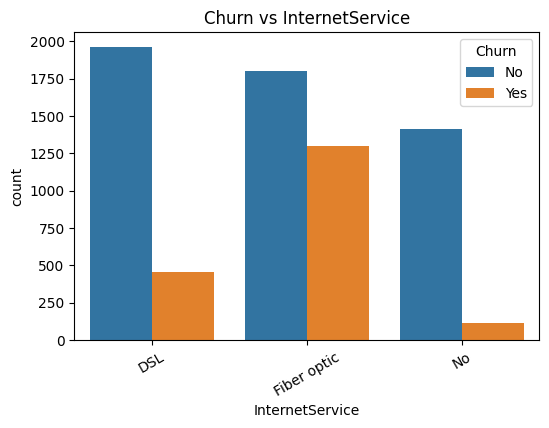

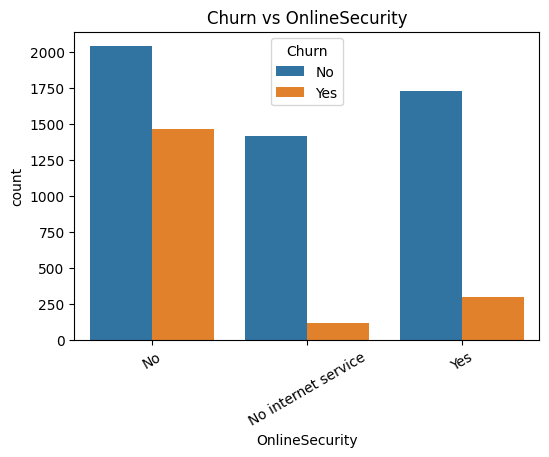

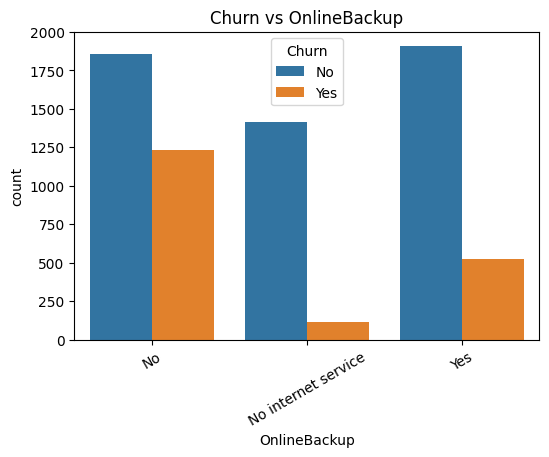

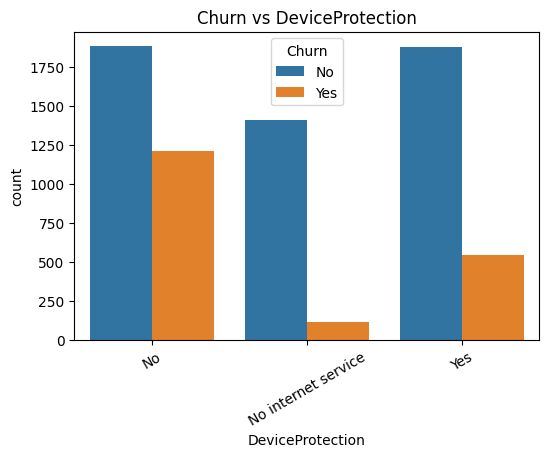

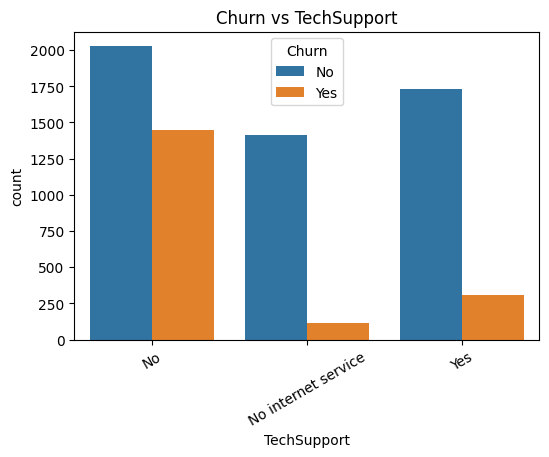

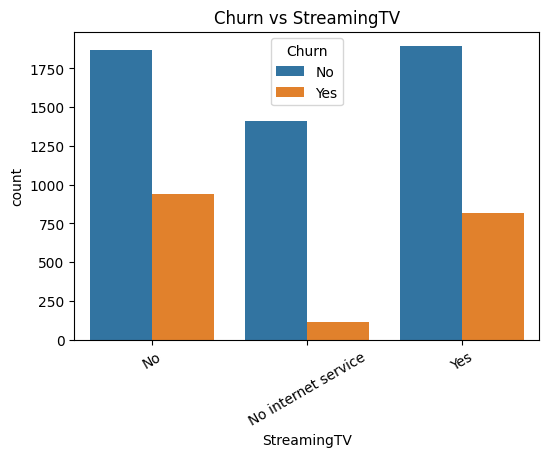

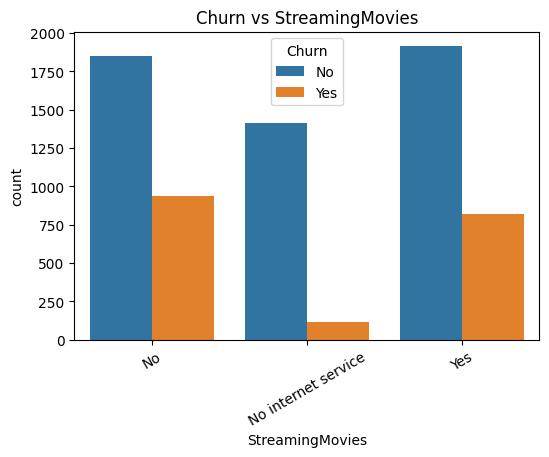

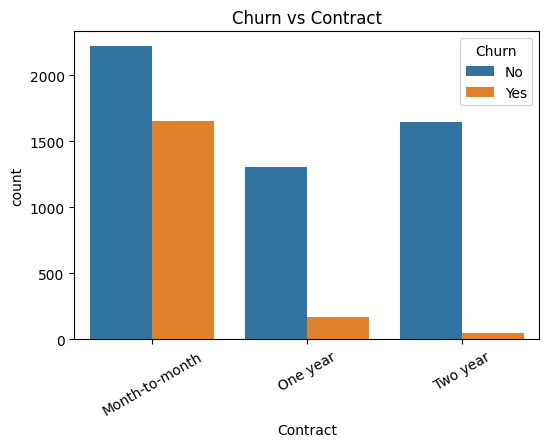

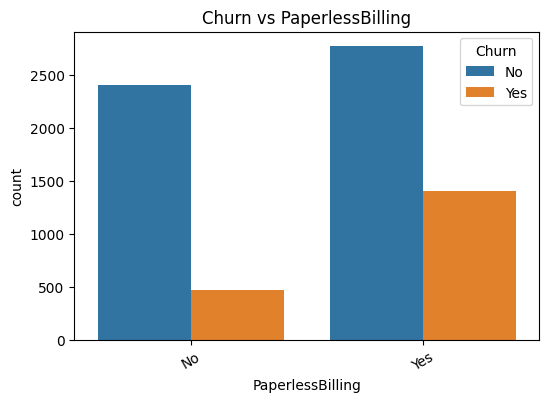

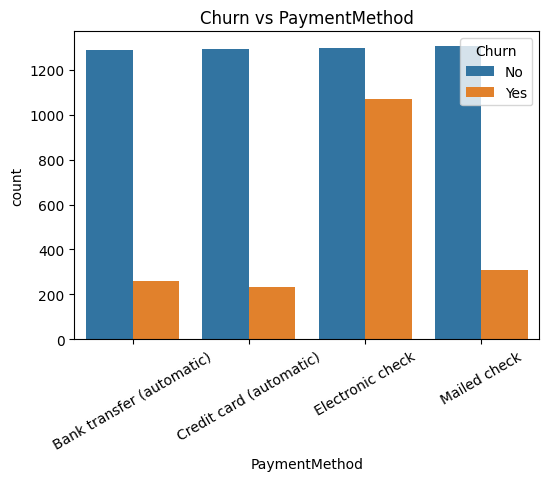

In [46]:
categorical_features = [
    "gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService", 
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", 
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", 
    "Contract", "PaperlessBilling", "PaymentMethod"
]

for col in categorical_features:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, hue="Churn")
    plt.title(f"Churn vs {col}")
    plt.xticks(rotation=30)
    plt.show()

On va comparer les distributions :

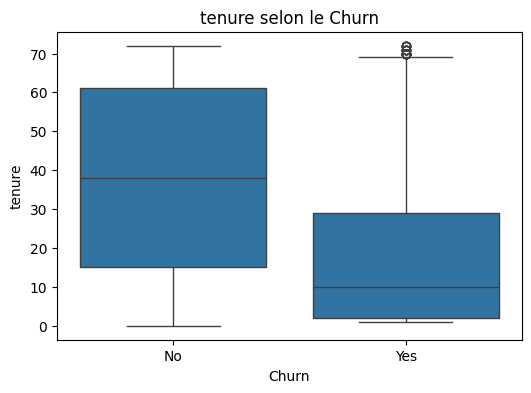

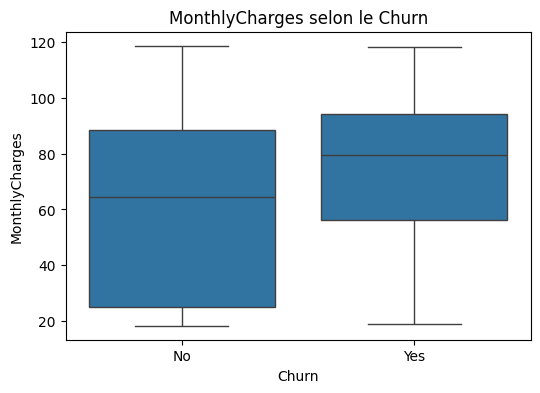

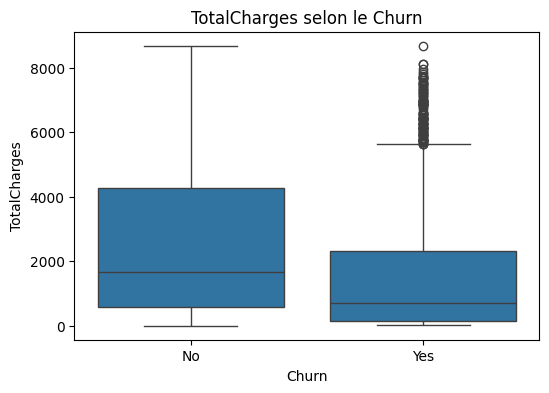

In [47]:
numerical_features = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in numerical_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x="Churn", y=col)
    plt.title(f"{col} selon le Churn")
    plt.show()


# Interprétation des résultats

---

## Variables catégorielles

### 1. Gender
- **Observation** : La répartition homme/femme est quasiment identique entre churn et non-churn.  
- **Conclusion** : Le genre n’est pas un facteur significatif de résiliation.  

### 2. SeniorCitizen
- **Observation** : Les clients seniors (1 = oui) ont un **taux de churn plus élevé**.  
- **Conclusion business** : Les seniors représentent une population plus à risque. Un accompagnement spécifique ou des offres adaptées pourraient réduire leur résiliation.  

### 3. Partner & Dependents
- **Observation** :  
  - Les clients sans partenaire ou sans dépendants ont un taux de churn plus fort.  
- **Conclusion business** : Les ménages seuls semblent moins fidèles. Les offres “famille” ou “multi-lignes” pourraient renforcer la rétention.  

### 4. InternetService
- **Observation** :  
  - Les clients **DSL** → churn plus faible.  
  - Les clients **Fiber optic** → churn beaucoup plus élevé.  
- **Conclusion business** : La fibre attire mais génère aussi de la volatilité (probablement à cause de la concurrence et des prix).  

### 5. OnlineSecurity, TechSupport, DeviceProtection
- **Observation** : Les clients **sans services additionnels** (sécurité, support technique, protection d’appareil) churnent nettement plus.  
- **Conclusion business** : Les services complémentaires sont des leviers de fidélisation.  

### 6. Contract
- **Observation** :  
  - **Month-to-month** → churn très élevé.  
  - **One year** → churn modéré.  
  - **Two year** → churn quasi inexistant.  
- **Conclusion business** : Les contrats longs limitent fortement le churn.  

### 7. PaymentMethod
- **Observation** :  
  - **Electronic check** → taux de churn très fort.  
  - Les autres moyens de paiement (virement auto, carte de crédit) → churn plus faible.  
- **Conclusion business** : Méthode de paiement = indicateur de risque. Les clients en paiement électronique nécessitent un suivi spécifique.  

---

## Variables numériques

### 1. Tenure (ancienneté)
- **Observation** : Les clients récents (< 12 mois) ont un fort taux de churn.  
- **Conclusion business** : La première année est critique → il faut renforcer la fidélisation dès l’onboarding.  

### 2. MonthlyCharges (facture mensuelle)
- **Observation** :  
  - Les clients avec des factures élevées (~70–100$) churnent plus.  
- **Conclusion business** : Les prix élevés augmentent le risque de résiliation → travailler sur la perception de valeur ou proposer des forfaits ajustés.  

### 3. TotalCharges
- **Observation** : Les clients avec un **TotalCharges faible** (donc récents) churnent davantage.  
- **Conclusion business** : Encore un indicateur que le churn est concentré chez les nouveaux abonnés.  

---

# Synthèse

- **Facteurs à fort impact sur le churn** : type de contrat, type d’Internet (fibre), services additionnels (sécurité, support, etc.), méthode de paiement, ancienneté, montant de la facture.  
- **Facteurs secondaires** : âge (SeniorCitizen), structure familiale (Partner/Dependents).  
- **Facteurs neutres** : genre.  

---

# Recommandations business

1. **Cibler les clients en contrat mensuel** avec des offres d’engagement (remises, bonus, upgrades gratuits).  
2. **Renforcer l’onboarding** des nouveaux clients (< 1 an) : support client proactif, offres de bienvenue évolutives.  
3. **Valoriser les services additionnels** (sécurité, support) car ils augmentent la rétention.  
4. **Surveiller les clients fibre** → ajuster la qualité de service et les prix pour réduire l’attrition.  
5. **Agir sur la tarification** pour les clients avec factures élevées (packs personnalisés, réductions sur options).  
6. **Suivi spécifique pour les clients Electronic Check** → proposer un changement de mode de paiement plus stable (prélèvement automatique).  


## Corrélations numériques

Objectif : voir si les features numériques sont corrélées entre elles et avec le churn.

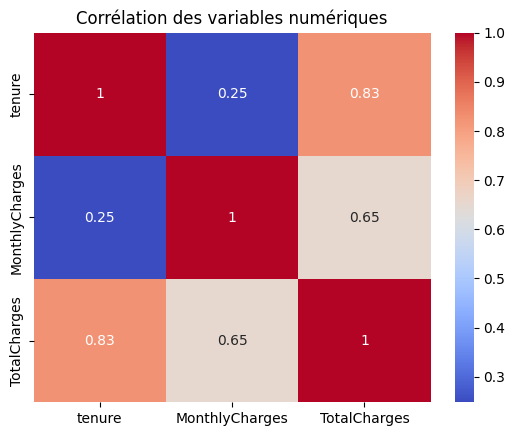

In [48]:
corr = df[['tenure','MonthlyCharges','TotalCharges']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Corrélation des variables numériques")
plt.show()


### Graphe 5 : Corrélation des variables numériques

tenure et TotalCharges → forte corrélation (0.83).
➝ Logique : plus un client reste longtemps, plus il paie au total.

MonthlyCharges et TotalCharges → corrélation modérée (0.65).
➝ Total dépend à la fois de la facture mensuelle et de la durée d’abonnement.

tenure et MonthlyCharges → faible corrélation (0.25).
➝ L’ancienneté d’un client n’influence pas vraiment le montant de son abonnement mensuel (les prix sont déterminés par le type d’offre).

Conclusion business :

TotalCharges apporte peu d’information supplémentaire par rapport à tenure et MonthlyCharges.

On pourra envisager de supprimer TotalCharges ou le transformer pour éviter la multicolinéarité dans certains modèles (ex: régression logistique, SVM linéaire), ça peut fausser les coefficients.

Par contre pour les modèles tree-based (Random Forest, XGBoost) → pas besoin de supprimer TotalCharges (ces modèles gèrent bien la corrélation).